<a href="https://colab.research.google.com/github/vedant-sangrame/Machine-Learning-Projects/blob/main/ML_TAE1_Model_1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Name: Vedant Sangrame**

**Topic: Accident Severity Prediction**

**Model: 1) Logistic Regression**

In [ ]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score

from sklearn.linear_model import LogisticRegression

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
path = "/content/drive/MyDrive/ML_dataset/US_Accidents_March23.csv"

df = pd.read_csv(path, nrows=150000)

df.head()

,ID,Source,Severity,Start_Time,End_Time,Start_Lat,Start_Lng,End_Lat,End_Lng,Distance(mi),...,Roundabout,Station,Stop,Traffic_Calming,Traffic_Signal,Turning_Loop,Sunrise_Sunset,Civil_Twilight,Nautical_Twilight,Astronomical_Twilight
0,A-1,Source2,3,2016-02-08 05:46:00,2016-02-08 11:00:00,39.865147,-84.058723,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Night
1,A-2,Source2,2,2016-02-08 06:07:59,2016-02-08 06:37:59,39.928059,-82.831184,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Night,Night,Day
2,A-3,Source2,2,2016-02-08 06:49:27,2016-02-08 07:19:27,39.063148,-84.032608,NaN,NaN,0.01,...,False,False,False,False,True,False,Night,Night,Day,Day
3,A-4,Source2,3,2016-02-08 07:23:34,2016-02-08 07:53:34,39.747753,-84.205582,NaN,NaN,0.01,...,False,False,False,False,False,False,Night,Day,Day,Day
4,A-5,Source2,2,2016-02-08 07:39:07,2016-02-08 08:09:07,39.627781,-84.188354,NaN,NaN,0.01,...,False,False,False,False,True,False,Day,Day,Day,Day


In [ ]:
df = df.sample(50000, random_state=42)

print(df.shape)

(50000, 46)


In [ ]:
data = df[['Severity','Start_Lat','Start_Lng','Distance(mi)',
           'Temperature(F)','Humidity(%)','Pressure(in)',
           'Visibility(mi)','Wind_Speed(mph)']]

data = data.dropna()

data.head()

,Severity,Start_Lat,Start_Lng,Distance(mi),Temperature(F),Humidity(%),Pressure(in),Visibility(mi),Wind_Speed(mph)
59770,3,33.825497,-118.228226,0.01,62.1,70.0,30.00,10.0,3.5
21362,3,37.915596,-122.065567,0.00,72.0,29.0,29.85,10.0,8.1
127324,3,25.985050,-80.165512,0.01,75.0,69.0,30.01,10.0,4.6
140509,3,28.008474,-82.453362,0.00,80.1,69.0,30.17,10.0,4.6
144297,3,26.331472,-81.750259,0.00,89.6,62.0,29.99,10.0,5.8


In [ ]:
X = data.drop('Severity', axis=1)
y = data['Severity']

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [ ]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

y_pred_lr = lr.predict(X_test)

print("Logistic Regression Accuracy:", accuracy_score(y_test, y_pred_lr))

Logistic Regression Accuracy: 0.5766799948407069


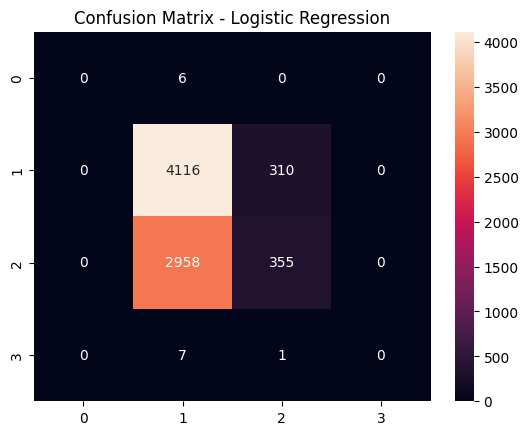

In [ ]:
cm_lr = confusion_matrix(y_test, y_pred_lr)

sns.heatmap(cm_lr, annot=True, fmt='d')

plt.title("Confusion Matrix - Logistic Regression")
plt.show()